<a href="https://colab.research.google.com/github/ankurdev1-drth/Deep_Learning-/blob/main/02_Training_Deep_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [1]:
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import torch

layer = nn.Linear(40, 10)
layer.weight.data *= 6 ** 0.5  # kaiming init (or 3 ** 0.5 for LeCun)
torch.zero_(layer.bias.data)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [3]:
layer.weight.shape

torch.Size([10, 40])

In [4]:
layer.bias.shape

torch.Size([10])

In [5]:
# another way to for initialization
nn.init.kaiming_uniform_(layer.weight)
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)

This is clearer and less error prone as compared to the first approach

For applying initialization to the weights of every `nn.Linear` layer in a model the simples option is to write a little function that takes a module, checks whether it's an instance of the `nn.Linear` class, and if so , applies the desired initialization function to its weights. and the function can be then applied using the `apply()` method

In [6]:
def use_he_init(module):
  if isinstance(module, nn.Linear):
    nn.init.kaiming_uniform_(module.weight)
    nn.init.zeros_(module.bias)

module = nn.Sequential(
    nn.Linear(40, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
    nn.ReLU()
    )
module.apply(use_he_init)

Sequential(
  (0): Linear(in_features=40, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=1, bias=True)
  (3): ReLU()
)

### Leaky ReLU

In [7]:
alpha = 0.2
model = nn.Sequential(
    nn.Linear(50, 40), #0
    nn.LeakyReLU(negative_slope=alpha), #1
    nn.Linear(40, 20), #2
    nn.LeakyReLU(negative_slope=alpha) #3

)
nn.init.kaiming_uniform_(model[0].weight, alpha,
nonlinearity="leaky_relu")
nn.init.kaiming_uniform_(model[2].weight, alpha,nonlinearity="leaky_relu")

Parameter containing:
tensor([[-3.1591e-01,  3.7324e-02, -2.5109e-01, -2.7563e-01, -1.5928e-01,
          1.1021e-01, -2.9378e-01, -2.1787e-01, -1.2861e-01, -2.3956e-01,
          2.2454e-01,  3.7003e-01, -3.7441e-01,  2.8309e-01, -1.0029e-01,
         -3.2919e-02, -3.5773e-01, -4.3469e-02, -1.7465e-01,  8.6213e-03,
          2.9938e-01, -3.2609e-01,  3.0578e-01, -6.8405e-02,  8.7940e-02,
          6.9393e-02, -2.1270e-02,  2.4545e-01,  1.4083e-01,  3.6566e-01,
          5.2136e-02, -8.0224e-02, -1.6849e-01,  6.1653e-02,  5.8213e-02,
         -2.5124e-01,  9.3146e-02, -1.9604e-01,  8.1963e-02,  1.3812e-01],
        [ 2.8657e-01,  4.7769e-02,  1.8154e-01,  1.3491e-01, -3.8456e-02,
         -6.1820e-02,  3.8871e-02, -2.2138e-01,  1.3646e-01,  7.2523e-02,
         -2.9855e-01,  2.9539e-01, -1.8227e-01,  2.1014e-01, -3.2912e-01,
         -2.1895e-01,  3.0508e-01, -1.3400e-01,  7.9648e-02, -2.0018e-01,
         -3.3212e-02, -5.3806e-02, -3.7314e-01,  1.2728e-01,  9.9775e-02,
          1.606

### Batch Normalization

In [8]:
model = nn.Sequential(
    nn.Flatten(),
    nn.BatchNorm1d(1 * 28 * 28),
    nn.Linear(1 * 28 * 28,  300),
    nn.ReLU(),
    nn.BatchNorm1d(300),
    nn.Linear(300, 100),
    nn.ReLU(),
    nn.BatchNorm1d(100),
    nn.Linear(100, 10)
)

In [9]:
dict(model[1].named_parameters()).keys()

dict_keys(['weight', 'bias'])

In [10]:
dict(model[1].named_buffers()).keys()

dict_keys(['running_mean', 'running_var', 'num_batches_tracked'])

In [11]:
dict(model[1].named_children()).keys()

dict_keys([])

In [12]:
dict(model[1].named_modules()).keys()

dict_keys([''])

Note:
- if BN layers before the activation functions, we can also remove the bias term from the previous `nn.Linear` layers by setting the `bias` hyperparameter to `False`.

In [13]:
Model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 300, bias=False),
    nn.BatchNorm1d(300),
    nn.ReLU(),
    nn.Linear(300, 100, bias=False),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Linear(100, 10)
)

### Layer Normalization

In [14]:
inputs = torch.randn(32, 3, 100, 200)   # batch of random RGB images
layer_norm = nn.LayerNorm([100, 200])
result = layer_norm(inputs)
result

tensor([[[[ 0.4224, -0.3339,  1.6179,  ..., -0.2515,  2.2873,  0.5753],
          [ 0.9986,  0.1940, -1.9689,  ...,  1.6533,  2.1697, -1.0507],
          [-2.1265, -0.1441,  1.8112,  ...,  1.1016, -0.5273,  0.8472],
          ...,
          [ 0.7220,  0.0646,  0.2094,  ..., -0.1252,  0.5842,  0.9912],
          [-1.0529,  0.7530, -1.0975,  ...,  1.6514, -0.1591,  0.1746],
          [ 0.5276, -0.8223,  0.7019,  ...,  0.1564, -0.2558, -0.1705]],

         [[-0.5140, -3.0427, -0.3202,  ..., -1.2390, -0.5225, -0.1876],
          [-1.1038,  0.7472,  0.7209,  ..., -0.8944, -1.3552, -0.1341],
          [-1.7199, -0.9779,  0.9300,  ...,  0.5107,  0.2618, -0.9628],
          ...,
          [ 0.0158, -0.8191,  0.1365,  ...,  0.4724,  1.4239,  0.8623],
          [ 1.0844,  0.1222,  0.3822,  ...,  1.4010,  0.4358, -1.5964],
          [ 1.6209,  1.4630, -1.8065,  ..., -2.2556,  0.9421, -0.0561]],

         [[ 0.1567, -1.5614,  1.2392,  ..., -1.2945, -1.9986,  0.7550],
          [ 2.2182, -0.0404, -

In [15]:
# method 2 to perform the same thing as above!
means = inputs.mean(dim=[2,3], keepdim=True)  #shape [32, 3, 1, 1]
vars_ = inputs.var(dim=[2,3], keepdim=True, unbiased=False) # shape: same
stds = torch.sqrt(vars_ + layer_norm.eps) # eps is a smoothing term (1e-5)
result = layer_norm.weight * (inputs - means) / stds + layer_norm.bias

In [16]:
layer_norm = nn.LayerNorm([3, 100, 200])
result = layer_norm(inputs)

In [17]:
result

tensor([[[[ 4.1955e-01, -3.3816e-01,  1.6171e+00,  ..., -2.5553e-01,
            2.2878e+00,  5.7270e-01],
          [ 9.9677e-01,  1.9073e-01, -1.9761e+00,  ...,  1.6526e+00,
            2.1699e+00, -1.0562e+00],
          [-2.1339e+00, -1.4798e-01,  1.8108e+00,  ...,  1.0999e+00,
           -5.3183e-01,  8.4511e-01],
          ...,
          [ 7.1967e-01,  6.1055e-02,  2.0615e-01,  ..., -1.2904e-01,
            5.8162e-01,  9.8939e-01],
          [-1.0584e+00,  7.5076e-01, -1.1031e+00,  ...,  1.6508e+00,
           -1.6296e-01,  1.7127e-01],
          [ 5.2489e-01, -8.2738e-01,  6.9953e-01,  ...,  1.5304e-01,
           -2.5989e-01, -1.7439e-01]],

         [[-5.2114e-01, -3.0733e+00, -3.2551e-01,  ..., -1.2528e+00,
           -5.2969e-01, -1.9168e-01],
          [-1.1164e+00,  7.5173e-01,  7.2522e-01,  ..., -9.0503e-01,
           -1.3701e+00, -1.3770e-01],
          [-1.7382e+00, -9.8931e-01,  9.3629e-01,  ...,  5.1311e-01,
            2.6187e-01, -9.7404e-01],
          ...,
     

## Gradient Clipping

See the line nn.utils.clip_grad_norm_(...) in the training function in the next section.

# Reusing Pretrained Layers

### Transfer Learning with PyTorch

- X_train_A = images of all items except for T-shirts/tops and pullovers (classes 0 and 2 )
- X_train_B = first 20 images of Tshirt and Pullovers

The validation set and the test set are also split this way, but without restricting the number of images.

We will train a model on set A (classification task with 8 classes), and try to reuse it to tackle set B (binary classification). We hope to transfer a little bit of knowledge from task A to task B, since classes in set A (trousers, dresses, coats, sandals, shirts, sneakers, bags, and ankle boots) are somewhat similar to classes in set B (T-shirts/tops and pullovers). However, since we are using Linear layers, only patterns that occur at the same location can be reused (in contrast, convolutional layers will transfer much better, since learned patterns can be detected anywhere on the image)


In [18]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml


fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False) #as_frames = False for getting the numpy arrays instead of pandas dataframe/series
X = torch.FloatTensor(fashion_mnist.data.reshape(-1, 1, 28, 28) / 255.)
y = torch.from_numpy(fashion_mnist.target.astype(int))
in_B = (y == 0) | (y == 2)  # Pullover or T-shirt/top
X_A, y_A = X[~in_B], y[~in_B]
y_A = torch.maximum(y_A - 2, torch.tensor(0))  # [1,3,4,5,6,7,8,9] => [0,..,7]
X_B, y_B = X[in_B], (y[in_B] == 2).to(dtype=torch.float32).view(-1, 1)

train_set_A = TensorDataset(X_A[:-7_000], y_A[:-7000])
valid_set_A = TensorDataset(X_A[-7_000:-5000], y_A[-7000:-5000])
test_set_A = TensorDataset(X_A[-5_000:], y_A[-5000:])
train_set_B = TensorDataset(X_B[:20], y_B[:20])
valid_set_B = TensorDataset(X_B[20:5000], y_B[20:5000])
test_set_B = TensorDataset(X_B[5_000:], y_B[5000:])

train_loader_A = DataLoader(train_set_A, batch_size=32, shuffle=True)
valid_loader_A = DataLoader(valid_set_A, batch_size=32)
test_loader_A = DataLoader(test_set_A, batch_size=32)
train_loader_B = DataLoader(train_set_B, batch_size=32, shuffle=True)
valid_loader_B = DataLoader(valid_set_B, batch_size=32)
test_loader_B = DataLoader(test_set_B, batch_size=32)

In [19]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device


'cpu'

In [20]:
%pip install torchmetrics


import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            # Uncomment to activate gradient clipping:
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.4 MB/s eta 0:00:00


In [21]:
torch.manual_seed(42)

model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 8)
  )
model_A = model_A.to(device)

In [22]:
model_A.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=8, bias=True)
)

In [23]:
n_epochs = 20
optimizer = torch.optim.SGD(model_A.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=8).to(device)
history_A = train(model_A, optimizer, loss_fn, accuracy, train_loader_A, valid_loader_A, n_epochs )

Epoch 1/20, train loss: 0.8492, train metric: 0.7197, valid metric: 0.8120
Epoch 2/20, train loss: 0.4533, train metric: 0.8487, valid metric: 0.8620
Epoch 3/20, train loss: 0.3771, train metric: 0.8727, valid metric: 0.8685
Epoch 4/20, train loss: 0.3405, train metric: 0.8827, valid metric: 0.8890
Epoch 5/20, train loss: 0.3184, train metric: 0.8904, valid metric: 0.8825
Epoch 6/20, train loss: 0.3032, train metric: 0.8953, valid metric: 0.8880
Epoch 7/20, train loss: 0.2911, train metric: 0.8999, valid metric: 0.8910
Epoch 8/20, train loss: 0.2817, train metric: 0.9031, valid metric: 0.8960
Epoch 9/20, train loss: 0.2735, train metric: 0.9053, valid metric: 0.8985
Epoch 10/20, train loss: 0.2666, train metric: 0.9083, valid metric: 0.8900
Epoch 11/20, train loss: 0.2610, train metric: 0.9108, valid metric: 0.9025
Epoch 12/20, train loss: 0.2546, train metric: 0.9127, valid metric: 0.8985
Epoch 13/20, train loss: 0.2502, train metric: 0.9146, valid metric: 0.8860
Epoch 14/20, train lo

In [24]:
torch.manual_seed(42)
model_B = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
).to(device)

In [25]:
model_B.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=1, bias=True)
)

In [26]:
n_epochs = 20
optimizer = torch.optim.SGD(model_B.parameters(), lr=0.001)
loss_fn = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B, optimizer, loss_fn, accuracy, train_loader_B, valid_loader_B, n_epochs)

Epoch 1/20, train loss: 0.7110, train metric: 0.5000, valid metric: 0.4914
Epoch 2/20, train loss: 0.7083, train metric: 0.5000, valid metric: 0.4954
Epoch 3/20, train loss: 0.7055, train metric: 0.5000, valid metric: 0.4976
Epoch 4/20, train loss: 0.7028, train metric: 0.5000, valid metric: 0.5008
Epoch 5/20, train loss: 0.7001, train metric: 0.5000, valid metric: 0.5034
Epoch 6/20, train loss: 0.6974, train metric: 0.5000, valid metric: 0.5080
Epoch 7/20, train loss: 0.6947, train metric: 0.5000, valid metric: 0.5118
Epoch 8/20, train loss: 0.6920, train metric: 0.5000, valid metric: 0.5159
Epoch 9/20, train loss: 0.6893, train metric: 0.5000, valid metric: 0.5197
Epoch 10/20, train loss: 0.6866, train metric: 0.5000, valid metric: 0.5225
Epoch 11/20, train loss: 0.6840, train metric: 0.5000, valid metric: 0.5263
Epoch 12/20, train loss: 0.6813, train metric: 0.5000, valid metric: 0.5311
Epoch 13/20, train loss: 0.6787, train metric: 0.5000, valid metric: 0.5339
Epoch 14/20, train lo

In [27]:
# reusing all the layers except the output layer
import copy

torch.manual_seed(42)
reused_layer = copy.deepcopy(model_A[: -1])
model_B_on_A = nn.Sequential(
    *reused_layer,
    nn.Linear(100, 1) # new output layer for task B
).to(device)

Note:
- `copy.deepcopy()` function to copy all the modules and submodules in `nn.Sequential` module
- model_B_on_A is another `nn.Sequential` module based on the reused layers of model A plus a new output layer for task B it has a single output since task B is binary classification.

In [28]:
# freezing the reused layers during the first few epochs:
for layer in model_B_on_A[:-1]:
  for param in layer.parameters():
    param.requires_grad = False


In [29]:
n_epochs = 10
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B_on_A, optimizer, xentropy, accuracy,
                  train_loader_B, valid_loader_B, n_epochs)

Epoch 1/10, train loss: 0.6172, train metric: 0.4000, valid metric: 0.5378
Epoch 2/10, train loss: 0.5871, train metric: 0.4500, valid metric: 0.5759
Epoch 3/10, train loss: 0.5609, train metric: 0.6500, valid metric: 0.6373
Epoch 4/10, train loss: 0.5385, train metric: 0.8000, valid metric: 0.7124
Epoch 5/10, train loss: 0.5201, train metric: 0.8500, valid metric: 0.7817
Epoch 6/10, train loss: 0.5055, train metric: 0.8500, valid metric: 0.8327
Epoch 7/10, train loss: 0.4945, train metric: 0.9000, valid metric: 0.8639
Epoch 8/10, train loss: 0.4863, train metric: 0.9000, valid metric: 0.8791
Epoch 9/10, train loss: 0.4794, train metric: 0.8500, valid metric: 0.8851
Epoch 10/10, train loss: 0.4729, train metric: 0.8500, valid metric: 0.8888


In [30]:
# unfreezing the reused layers during the first few epochs:
for layer in model_B_on_A[2:]:
  for param in layer.parameters():
    param.requires_grad = True

In [31]:
n_epochs = 20
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.01)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B_on_A, optimizer, xentropy, accuracy,
                train_loader_B, valid_loader_B, n_epochs)

Epoch 1/20, train loss: 0.4666, train metric: 0.8500, valid metric: 0.8960
Epoch 2/20, train loss: 0.4523, train metric: 0.9000, valid metric: 0.9024
Epoch 3/20, train loss: 0.4384, train metric: 0.9000, valid metric: 0.9070
Epoch 4/20, train loss: 0.4249, train metric: 0.9500, valid metric: 0.9112
Epoch 5/20, train loss: 0.4119, train metric: 0.9500, valid metric: 0.9137
Epoch 6/20, train loss: 0.3993, train metric: 0.9500, valid metric: 0.9171
Epoch 7/20, train loss: 0.3871, train metric: 0.9500, valid metric: 0.9181
Epoch 8/20, train loss: 0.3754, train metric: 0.9500, valid metric: 0.9197
Epoch 9/20, train loss: 0.3640, train metric: 0.9500, valid metric: 0.9213
Epoch 10/20, train loss: 0.3530, train metric: 0.9500, valid metric: 0.9225
Epoch 11/20, train loss: 0.3424, train metric: 0.9500, valid metric: 0.9231
Epoch 12/20, train loss: 0.3321, train metric: 0.9500, valid metric: 0.9245
Epoch 13/20, train loss: 0.3221, train metric: 0.9500, valid metric: 0.9255
Epoch 14/20, train lo

In [32]:
evaluate_tm(model_B_on_A, test_loader_B, accuracy)

tensor(0.9356)

## Faster Optimizers

In [33]:

def build_model(seed=43):
  torch.manual_seed(seed)
  model = nn.Sequential(
      nn.Flatten(),
      nn.Linear(28 * 28, 100),
      nn.ReLU(),
      nn.Linear(100, 100),
      nn.ReLU(),
      nn.Linear(100, 100),
      nn.ReLU(),
      nn.Linear(100, 10)
  ).to(device)
  model.apply(use_he_init)
  return model

def test_optimizer(model, optimizer, n_epochs=10, batch_size=32):
  train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
  valid_loader = DataLoader(valid_set, batch_size=batch_size)
  test_loader = DataLoader(test_set, batch_size=32)
  xentropy = nn.CrossEntropyLoss()
  accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
  history = train(model, optimizer, xentropy, accuracy.to(device),
                  train_loader, valid_loader, n_epochs)
  return history, evaluate_tm(model, test_loader, accuracy)


In [34]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## Momentum Optimization

In [35]:
train_set = TensorDataset(X[:55_000], y[:55_000])
valid_set = TensorDataset(X[55_000:60_000], y[55_000:60_000])
test_set = TensorDataset(X[60_000:], y[60_000:])

model = build_model()
optimizer = torch.optim.SGD(model.parameters(), momentum=0.9, lr=0.01)
history_momentum, accuracy_momentum = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.5823, train metric: 0.7984, valid metric: 0.8316
Epoch 2/10, train loss: 0.4194, train metric: 0.8500, valid metric: 0.8590
Epoch 3/10, train loss: 0.3780, train metric: 0.8640, valid metric: 0.8684
Epoch 4/10, train loss: 0.3482, train metric: 0.8740, valid metric: 0.8712
Epoch 5/10, train loss: 0.3306, train metric: 0.8801, valid metric: 0.8760
Epoch 6/10, train loss: 0.3118, train metric: 0.8860, valid metric: 0.8682
Epoch 7/10, train loss: 0.3005, train metric: 0.8902, valid metric: 0.8776
Epoch 8/10, train loss: 0.2887, train metric: 0.8931, valid metric: 0.8568
Epoch 9/10, train loss: 0.2795, train metric: 0.8967, valid metric: 0.8808
Epoch 10/10, train loss: 0.2704, train metric: 0.9007, valid metric: 0.8720


### Nesterov Accelerated Gradient

In [36]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), momentum=0.9, nesterov=True, lr=0.01)
history_nesterov, accuracy_nesterov = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.5651, train metric: 0.8047, valid metric: 0.8406
Epoch 2/10, train loss: 0.4168, train metric: 0.8525, valid metric: 0.8582
Epoch 3/10, train loss: 0.3772, train metric: 0.8646, valid metric: 0.8718
Epoch 4/10, train loss: 0.3477, train metric: 0.8745, valid metric: 0.8698
Epoch 5/10, train loss: 0.3292, train metric: 0.8806, valid metric: 0.8750
Epoch 6/10, train loss: 0.3123, train metric: 0.8863, valid metric: 0.8708
Epoch 7/10, train loss: 0.2992, train metric: 0.8890, valid metric: 0.8792
Epoch 8/10, train loss: 0.2873, train metric: 0.8941, valid metric: 0.8810
Epoch 9/10, train loss: 0.2786, train metric: 0.8973, valid metric: 0.8768
Epoch 10/10, train loss: 0.2694, train metric: 0.9004, valid metric: 0.8748


## AdaGrad

In [37]:
model = build_model()
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01)
history_adagrad, accuracy_adagrad = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.4978, train metric: 0.8227, valid metric: 0.8606
Epoch 2/10, train loss: 0.3685, train metric: 0.8672, valid metric: 0.8666
Epoch 3/10, train loss: 0.3362, train metric: 0.8783, valid metric: 0.8756
Epoch 4/10, train loss: 0.3166, train metric: 0.8854, valid metric: 0.8788
Epoch 5/10, train loss: 0.3020, train metric: 0.8913, valid metric: 0.8742
Epoch 6/10, train loss: 0.2908, train metric: 0.8951, valid metric: 0.8796
Epoch 7/10, train loss: 0.2811, train metric: 0.8983, valid metric: 0.8828
Epoch 8/10, train loss: 0.2732, train metric: 0.9010, valid metric: 0.8846
Epoch 9/10, train loss: 0.2665, train metric: 0.9030, valid metric: 0.8834
Epoch 10/10, train loss: 0.2607, train metric: 0.9058, valid metric: 0.8882


## RMSProp

In [38]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.01, alpha=0.9)
history_rmsprop, accuracy_rmsprop = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.7634, train metric: 0.7633, valid metric: 0.8204
Epoch 2/10, train loss: 0.6496, train metric: 0.8132, valid metric: 0.8102
Epoch 3/10, train loss: 0.6482, train metric: 0.8205, valid metric: 0.8396
Epoch 4/10, train loss: 0.6552, train metric: 0.8257, valid metric: 0.8314
Epoch 5/10, train loss: 0.6587, train metric: 0.8280, valid metric: 0.8318
Epoch 6/10, train loss: 0.6794, train metric: 0.8266, valid metric: 0.8446
Epoch 7/10, train loss: 0.6594, train metric: 0.8307, valid metric: 0.8330
Epoch 8/10, train loss: 0.6894, train metric: 0.8353, valid metric: 0.8412
Epoch 9/10, train loss: 0.7162, train metric: 0.8330, valid metric: 0.8288
Epoch 10/10, train loss: 0.7002, train metric: 0.8327, valid metric: 0.8382


## Adam Optimization

In [39]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05, betas=(0.9, 0.999))
history_adam, accuracy_adam = test_optimizer(model, optimizer)


Epoch 1/10, train loss: 1.7800, train metric: 0.3437, valid metric: 0.2062
Epoch 2/10, train loss: 1.7963, train metric: 0.1949, valid metric: 0.1922
Epoch 3/10, train loss: 1.7732, train metric: 0.1954, valid metric: 0.1976
Epoch 4/10, train loss: 1.9501, train metric: 0.1632, valid metric: 0.1042
Epoch 5/10, train loss: 2.5250, train metric: 0.0999, valid metric: 0.1052
Epoch 6/10, train loss: 2.3140, train metric: 0.0999, valid metric: 0.1052
Epoch 7/10, train loss: 2.3115, train metric: 0.1006, valid metric: 0.1042
Epoch 8/10, train loss: 2.3088, train metric: 0.1008, valid metric: 0.1042
Epoch 9/10, train loss: 2.3096, train metric: 0.1004, valid metric: 0.1006
Epoch 10/10, train loss: 2.3092, train metric: 0.0988, valid metric: 0.1030


### Adamax Optimization

In [40]:
model =  build_model()
optimizer = torch.optim.Adamax(model.parameters(), lr=0.03, betas=(0.9, 0.999))
history_adamax, accuracy_adamax = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.6195, train metric: 0.8013, valid metric: 0.8442
Epoch 2/10, train loss: 0.4366, train metric: 0.8431, valid metric: 0.8500
Epoch 3/10, train loss: 0.4135, train metric: 0.8517, valid metric: 0.8566
Epoch 4/10, train loss: 0.3914, train metric: 0.8599, valid metric: 0.8648
Epoch 5/10, train loss: 0.3786, train metric: 0.8649, valid metric: 0.8570
Epoch 6/10, train loss: 0.3653, train metric: 0.8699, valid metric: 0.8540
Epoch 7/10, train loss: 0.3582, train metric: 0.8726, valid metric: 0.8632
Epoch 8/10, train loss: 0.3499, train metric: 0.8745, valid metric: 0.8634
Epoch 9/10, train loss: 0.3446, train metric: 0.8758, valid metric: 0.8702
Epoch 10/10, train loss: 0.3348, train metric: 0.8794, valid metric: 0.8726


### Nadam Optimization

In [41]:
model = build_model()  # extra code
optimizer = torch.optim.NAdam(model.parameters(), betas=(0.9, 0.999), lr=0.05)
history_nadam, acc_nadam = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 2.4710, train metric: 0.0985, valid metric: 0.1044
Epoch 2/10, train loss: 2.3083, train metric: 0.0980, valid metric: 0.1044
Epoch 3/10, train loss: 2.3086, train metric: 0.1015, valid metric: 0.1030
Epoch 4/10, train loss: 2.3085, train metric: 0.0979, valid metric: 0.1044
Epoch 5/10, train loss: 2.3086, train metric: 0.0987, valid metric: 0.1044
Epoch 6/10, train loss: 2.3083, train metric: 0.1004, valid metric: 0.1044
Epoch 7/10, train loss: 2.3082, train metric: 0.1002, valid metric: 0.1042
Epoch 8/10, train loss: 2.3083, train metric: 0.1010, valid metric: 0.1042
Epoch 9/10, train loss: 2.3090, train metric: 0.1009, valid metric: 0.1006
Epoch 10/10, train loss: 2.3088, train metric: 0.0991, valid metric: 0.1030


### AdamW Optimization

In [42]:
model = build_model()
optimizer = torch.optim.AdamW(model.parameters(), betas=(0.9, 0.999), lr=0.03)
history_adamW, accuracy_adamw = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.9057, train metric: 0.6912, valid metric: 0.7046
Epoch 2/10, train loss: 0.8649, train metric: 0.6563, valid metric: 0.7054
Epoch 3/10, train loss: 0.7976, train metric: 0.6977, valid metric: 0.7092
Epoch 4/10, train loss: 0.7931, train metric: 0.6963, valid metric: 0.7000
Epoch 5/10, train loss: 0.8765, train metric: 0.6664, valid metric: 0.6788
Epoch 6/10, train loss: 0.9205, train metric: 0.6477, valid metric: 0.6694
Epoch 7/10, train loss: 0.8962, train metric: 0.6538, valid metric: 0.5800
Epoch 8/10, train loss: 1.0743, train metric: 0.5733, valid metric: 0.5944
Epoch 9/10, train loss: 1.0216, train metric: 0.6073, valid metric: 0.5822
Epoch 10/10, train loss: 1.0099, train metric: 0.6172, valid metric: 0.6618


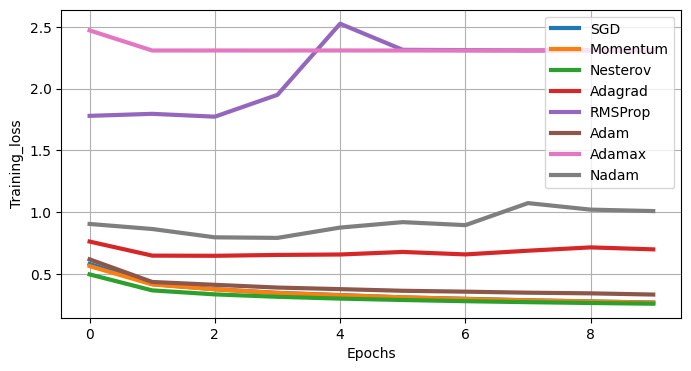

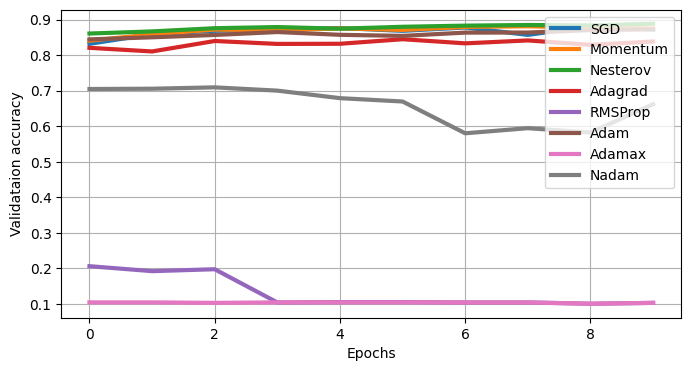

In [43]:
for plot in ("train_losses", "valid_metrics"):
  plt.figure(figsize=(8,4))
  opt_names = "SGD Momentum Nesterov Adagrad RMSProp Adam Adamax Nadam AdamW".split()
  for history, opt_name in zip(
      (history_momentum, history_nesterov, history_adagrad,
       history_rmsprop, history_adam, history_adamax, history_nadam,
       history_adamW), opt_names):
       plt.plot(history[plot], label=opt_name, linewidth=3)

  plt.grid()
  plt.xlabel("Epochs")
  plt.ylabel({"train_losses": "Training_loss", "valid_metrics": "Validataion accuracy"}[plot])
  plt.legend(loc="upper right")
  plt.show()

## Learning Rate Scheduling

In [44]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
exp_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1)

In [45]:
def train_with_scheduler(model, optimizer, loss_fn, metric, train_loader,
                         valid_loader, n_epochs, scheduler):
  history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
  for epoch in range(n_epochs):
    losses = []
    metric.reset()
    for X_batch, y_batch in train_loader:
      model.train()
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = loss_fn(y_pred, y_batch)
      losses.append(loss.item())
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      metric.update(y_pred, y_batch)
  history["train_losses"].append(np.mean(losses))
  history["train_metrics"].append(metric.compute().itemO())
  val_metric = evaluate_tm(model, valid_loader, metric).item()
  history["valid_metrics"].append(val_metric)
  print(f"Epoch{epoch + 1} / {n_epochs},"
        f"train loss : {history['train_losses'][-1]:.4f},"
        f"train metric: {history['train_metrics'][-1]:.4f}, "
        f"valid metric: {history['valid_metrics'][-1]:.4f}")
  if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
    scheduler.step(val_metric)
  else:
    scheduler.step()
  print(f"Learning rate: {scheduler.get_last_lr()[0]:.5f}")
  return history


In [46]:
def train_with_scheduler(model, optimizer, loss_fn, metric, train_loader,
                         valid_loader, n_epochs, scheduler):
  history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
  for epoch in range(n_epochs):
    losses = []
    metric.reset()
    for X_batch, y_batch in train_loader:
      model.train()
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = loss_fn(y_pred, y_batch)
      losses.append(loss.item())
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      metric.update(y_pred, y_batch)

    # Note: These should be inside the epoch loop to track progress
    history["train_losses"].append(np.mean(losses))
    history["train_metrics"].append(metric.compute().item())
    val_metric = evaluate_tm(model, valid_loader, metric).item()
    history["valid_metrics"].append(val_metric)

    print(f"Epoch {epoch + 1} / {n_epochs}, "
          f"train loss : {history['train_losses'][-1]:.4f}, "
          f"train metric: {history['train_metrics'][-1]:.4f}, "
          f"valid metric: {history['valid_metrics'][-1]:.4f}")

    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
      scheduler.step(val_metric)
    else:
      scheduler.step()

    # Use get_last_lr() for standard schedulers
    if not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        print(f"Learning rate: {scheduler.get_last_lr()[0]:.5f}")

  return history

In [47]:
def test_scheduler(model, optimizer, scheduler, n_epochs=10, batch_size=32):
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_set, batch_size=batch_size)
    test_loader = DataLoader(test_set, batch_size=32)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
    history = train_with_scheduler(
        model, optimizer, xentropy, accuracy, train_loader,
        valid_loader, n_epochs, scheduler
    )
    return history, evaluate_tm(model, test_loader, accuracy)

history_exp, acc_exp = test_scheduler(model, optimizer, exp_scheduler)

Epoch 1 / 10, train loss : 0.6774, train metric: 0.7687, valid metric: 0.8230
Learning rate: 0.00100
Epoch 2 / 10, train loss : 0.4653, train metric: 0.8396, valid metric: 0.8352
Learning rate: 0.00010
Epoch 3 / 10, train loss : 0.4555, train metric: 0.8421, valid metric: 0.8366
Learning rate: 0.00001
Epoch 4 / 10, train loss : 0.4543, train metric: 0.8430, valid metric: 0.8362
Learning rate: 0.00000
Epoch 5 / 10, train loss : 0.4542, train metric: 0.8431, valid metric: 0.8364
Learning rate: 0.00000
Epoch 6 / 10, train loss : 0.4541, train metric: 0.8431, valid metric: 0.8364
Learning rate: 0.00000
Epoch 7 / 10, train loss : 0.4541, train metric: 0.8431, valid metric: 0.8364
Learning rate: 0.00000
Epoch 8 / 10, train loss : 0.4542, train metric: 0.8431, valid metric: 0.8364
Learning rate: 0.00000
Epoch 9 / 10, train loss : 0.4541, train metric: 0.8431, valid metric: 0.8364
Learning rate: 0.00000
Epoch 10 / 10, train loss : 0.4542, train metric: 0.8431, valid metric: 0.8364
Learning rat

In [48]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
perf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.1
)

In [49]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

history_perf = train_with_scheduler(
    model, optimizer, xentropy, accuracy, train_loader,
    valid_loader, n_epochs=10, scheduler=perf_scheduler
)

Epoch 1 / 10, train loss : 0.5651, train metric: 0.7962, valid metric: 0.8464
Epoch 2 / 10, train loss : 0.4027, train metric: 0.8513, valid metric: 0.8540
Epoch 3 / 10, train loss : 0.3605, train metric: 0.8656, valid metric: 0.8666
Epoch 4 / 10, train loss : 0.3346, train metric: 0.8743, valid metric: 0.8686
Epoch 5 / 10, train loss : 0.3156, train metric: 0.8823, valid metric: 0.8514
Epoch 6 / 10, train loss : 0.3015, train metric: 0.8875, valid metric: 0.8766
Epoch 7 / 10, train loss : 0.2870, train metric: 0.8938, valid metric: 0.8770
Epoch 8 / 10, train loss : 0.2762, train metric: 0.8966, valid metric: 0.8720
Epoch 9 / 10, train loss : 0.2684, train metric: 0.8985, valid metric: 0.8826
Epoch 10 / 10, train loss : 0.2591, train metric: 0.9037, valid metric: 0.8830


In [50]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=3
)


In [51]:
# using lambda to wrap around the customly created function
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), betas=(0.9, 0.999), lr=0.05)
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lambda epoch: (min(epoch, 3) /3) * (1.0 - 0.1) + 0.1
)

In [52]:
def train_with_warmup(model, optimizer, loss_fn, metric, train_loader,
                      valid_loader, n_epochs, warmup_scheduler, scheduler):
  history = {"train_losses":[], "train_metrics": [], "valid_metrics": []}
  for epoch in range(n_epochs):

    warmup_scheduler.step()

    losses = []
    metric.reset()

    for X_batch, y_batch in train_loader:
      model.train()
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = loss_fn(y_pred, y_batch)
      losses.append(loss.item())
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      metric.update(y_pred, y_batch)

    history["train_losses"].append(np.mean(losses))
    history["train_metrics"].append(metric.compute().item())
    val_metric = evaluate_tm(model, valid_loader, metric).item()
    history["valid_metrics"].append(val_metric)

    print(f"Epoch {epoch + 1}/ {n_epochs}, "
          f"train loss: {history['train_losses'][-1]:.4f}, "
          f"valid metric: {history['valid_metrics'][-1]:.4f}")

    if epoch >= 3:
      # Pass validation metric to scheduler if it's ReduceLROnPlateau
      if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
          scheduler.step(val_metric)
      else:
          scheduler.step()

    lr = optimizer.param_groups[0]['lr']
    print(f"Learning rate : {lr:.5f}")
  return history

def test_warmup_scheduler(model, optimizer, warmup_scheduler, scheduler,
                          n_epochs=10, batch_size=32):
  train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
  valid_loader = DataLoader(valid_set, batch_size=batch_size)
  test_loader = DataLoader(test_set, batch_size=32)
  xentropy = nn.CrossEntropyLoss()
  accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)
  history = train_with_warmup(
      model, optimizer, xentropy, accuracy, train_loader,
      valid_loader, n_epochs, warmup_scheduler, scheduler
  )
  return history, evaluate_tm(model, test_loader, accuracy)

In [53]:
perf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.1
)
test_warmup_scheduler(model, optimizer, warmup_scheduler, perf_scheduler,
                      n_epochs=10, batch_size=32)

/tmp/ipykernel_650/1828876987.py:6: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warmup_scheduler.step()


Epoch 1/ 10, train loss: 0.7214, valid metric: 0.7978
Learning rate : 0.02000
Epoch 2/ 10, train loss: 0.8081, valid metric: 0.6184
Learning rate : 0.03500
Epoch 3/ 10, train loss: 1.6324, valid metric: 0.2126
Learning rate : 0.05000
Epoch 4/ 10, train loss: 1.7370, valid metric: 0.2362
Learning rate : 0.05000
Epoch 5/ 10, train loss: 1.7723, valid metric: 0.2038
Learning rate : 0.05000
Epoch 6/ 10, train loss: 1.9198, valid metric: 0.2382
Learning rate : 0.05000
Epoch 7/ 10, train loss: 1.7219, valid metric: 0.2108
Learning rate : 0.05000
Epoch 8/ 10, train loss: 1.6387, valid metric: 0.2086
Learning rate : 0.05000
Epoch 9/ 10, train loss: 1.7148, valid metric: 0.2820
Learning rate : 0.05000
Epoch 10/ 10, train loss: 1.8524, valid metric: 0.1808
Learning rate : 0.05000


({'train_losses': [np.float64(0.721363766915303),
   np.float64(0.8080843087023535),
   np.float64(1.632393832866226),
   np.float64(1.7370142911047766),
   np.float64(1.7723334680954477),
   np.float64(1.9198055295766683),
   np.float64(1.721862766755189),
   np.float64(1.6387090538739464),
   np.float64(1.7148316251184443),
   np.float64(1.8524138535643262)],
  'train_metrics': [0.7421091198921204,
   0.7014181613922119,
   0.297036349773407,
   0.20369091629981995,
   0.22712726891040802,
   0.23532727360725403,
   0.22203636169433594,
   0.26018181443214417,
   0.21670909225940704,
   0.2523636221885681],
  'valid_metrics': [0.7978000044822693,
   0.618399977684021,
   0.2125999927520752,
   0.2362000048160553,
   0.2037999927997589,
   0.23819999396800995,
   0.21080000698566437,
   0.2085999995470047,
   0.28200000524520874,
   0.18080000579357147]},
 tensor(0.1745))

In [54]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), betas=(0.9, 0.999), lr=0.03)
cosine_repeat_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0 = 3, T_mult = 2, eta_min = 0.001
)


In [55]:
test_warmup_scheduler(model, optimizer, cosine_repeat_scheduler, perf_scheduler,
                      n_epochs=10, batch_size=32)

Epoch 1/ 10, train loss: 0.7550, valid metric: 0.7810
Learning rate : 0.02275
Epoch 2/ 10, train loss: 0.5430, valid metric: 0.8130
Learning rate : 0.00825
Epoch 3/ 10, train loss: 1.2824, valid metric: 0.4446
Learning rate : 0.03000
Epoch 4/ 10, train loss: 1.1534, valid metric: 0.5276
Learning rate : 0.02806
Epoch 5/ 10, train loss: 1.2122, valid metric: 0.4944
Learning rate : 0.02275
Epoch 6/ 10, train loss: 1.1402, valid metric: 0.4676
Learning rate : 0.01550
Epoch 7/ 10, train loss: 1.0993, valid metric: 0.5776
Learning rate : 0.00825
Epoch 8/ 10, train loss: 0.9957, valid metric: 0.5690
Learning rate : 0.00294
Epoch 9/ 10, train loss: 1.1780, valid metric: 0.5586
Learning rate : 0.03000
Epoch 10/ 10, train loss: 1.0892, valid metric: 0.4680
Learning rate : 0.02951


({'train_losses': [np.float64(0.7549824333766507),
   np.float64(0.5430376637529813),
   np.float64(1.2823517188351816),
   np.float64(1.153415489917997),
   np.float64(1.212238150394677),
   np.float64(1.1402313156208372),
   np.float64(1.0993366880150575),
   np.float64(0.9956797792718742),
   np.float64(1.17801850694359),
   np.float64(1.0892365063048157)],
  'train_metrics': [0.7370363473892212,
   0.8059999942779541,
   0.46058180928230286,
   0.4801636338233948,
   0.44516363739967346,
   0.47540000081062317,
   0.5003454685211182,
   0.5601454377174377,
   0.5113454461097717,
   0.5053636431694031],
  'valid_metrics': [0.781000018119812,
   0.8130000233650208,
   0.444599986076355,
   0.5275999903678894,
   0.4943999946117401,
   0.4675999879837036,
   0.5776000022888184,
   0.5690000057220459,
   0.5586000084877014,
   0.46799999475479126]},
 tensor(0.4644))

## Avoiding Overfitting through Regularization

### l1 and l2 regularization

In [56]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, weight_decay= 10 ** -4)   # here 1e-4 == 10 ** -4


In [57]:
test_warmup_scheduler(model, optimizer, cosine_repeat_scheduler, perf_scheduler,
                      n_epochs=20, batch_size=32)

Epoch 1/ 20, train loss: 0.6774, valid metric: 0.8222
Learning rate : 0.01000
Epoch 2/ 20, train loss: 0.4699, valid metric: 0.8426
Learning rate : 0.01000
Epoch 3/ 20, train loss: 0.4255, valid metric: 0.8508
Learning rate : 0.01000
Epoch 4/ 20, train loss: 0.3963, valid metric: 0.8590
Learning rate : 0.01000
Epoch 5/ 20, train loss: 0.3764, valid metric: 0.8584
Learning rate : 0.01000
Epoch 6/ 20, train loss: 0.3622, valid metric: 0.8638
Learning rate : 0.01000
Epoch 7/ 20, train loss: 0.3491, valid metric: 0.8614
Learning rate : 0.01000
Epoch 8/ 20, train loss: 0.3369, valid metric: 0.8658
Learning rate : 0.01000
Epoch 9/ 20, train loss: 0.3273, valid metric: 0.8738
Learning rate : 0.01000
Epoch 10/ 20, train loss: 0.3184, valid metric: 0.8794
Learning rate : 0.01000
Epoch 11/ 20, train loss: 0.3094, valid metric: 0.8766
Learning rate : 0.01000
Epoch 12/ 20, train loss: 0.3025, valid metric: 0.8800
Learning rate : 0.01000
Epoch 13/ 20, train loss: 0.2960, valid metric: 0.8736
Learni

({'train_losses': [np.float64(0.6773968448016171),
   np.float64(0.46992864248674926),
   np.float64(0.42546716061111384),
   np.float64(0.39625032657866843),
   np.float64(0.3764265487149332),
   np.float64(0.36215374271161616),
   np.float64(0.3490554020025482),
   np.float64(0.33693566196936725),
   np.float64(0.3273287018313527),
   np.float64(0.31840198497879013),
   np.float64(0.3093756000669007),
   np.float64(0.3024553337165302),
   np.float64(0.2959584471828685),
   np.float64(0.2895210731976111),
   np.float64(0.28298083319393197),
   np.float64(0.2777729233441882),
   np.float64(0.27195011474378517),
   np.float64(0.26769620974381836),
   np.float64(0.261982256262723),
   np.float64(0.2573440784372827)],
  'train_metrics': [0.7684727311134338,
   0.8340727090835571,
   0.8485999703407288,
   0.8587454557418823,
   0.8656363487243652,
   0.8699454665184021,
   0.8753454685211182,
   0.87867271900177,
   0.882418155670166,
   0.8851818442344666,
   0.8878727555274963,
   0.890

In [58]:
# training with a scheduler  to check if i can get a better performance
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), betas=(0.9, 0.999), lr=0.03)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
test_scheduler(model, optimizer, scheduler, n_epochs=20, batch_size=32)

Epoch 1 / 20, train loss : 0.9175, train metric: 0.6838, valid metric: 0.6832
Learning rate: 0.02927
Epoch 2 / 20, train loss : 0.7178, train metric: 0.7491, valid metric: 0.7378
Learning rate: 0.02714
Epoch 3 / 20, train loss : 0.7065, train metric: 0.7593, valid metric: 0.7646
Learning rate: 0.02382
Epoch 4 / 20, train loss : 0.7056, train metric: 0.7698, valid metric: 0.7490
Learning rate: 0.01964
Epoch 5 / 20, train loss : 0.7232, train metric: 0.7465, valid metric: 0.6546
Learning rate: 0.01500
Epoch 6 / 20, train loss : 0.7443, train metric: 0.7075, valid metric: 0.7170
Learning rate: 0.01036
Epoch 7 / 20, train loss : 0.6885, train metric: 0.7346, valid metric: 0.7212
Learning rate: 0.00618
Epoch 8 / 20, train loss : 0.6555, train metric: 0.7444, valid metric: 0.7506
Learning rate: 0.00286
Epoch 9 / 20, train loss : 0.6265, train metric: 0.7571, valid metric: 0.7534
Learning rate: 0.00073
Epoch 10 / 20, train loss : 0.6122, train metric: 0.7636, valid metric: 0.7544
Learning rat

({'train_losses': [np.float64(0.9174550362386421),
   np.float64(0.7178057550846525),
   np.float64(0.7064629172242055),
   np.float64(0.7056093775147682),
   np.float64(0.7232204305269192),
   np.float64(0.7443130964314681),
   np.float64(0.6885074161300831),
   np.float64(0.6554784151861458),
   np.float64(0.6265095085720463),
   np.float64(0.6121645995858382),
   np.float64(0.6072385318321568),
   np.float64(0.6074644416796044),
   np.float64(0.6130602421578174),
   np.float64(0.634574450868864),
   np.float64(0.6348363547875758),
   np.float64(0.6793082604025463),
   np.float64(0.714572626527414),
   np.float64(0.7531988063893255),
   np.float64(0.7972726454701515),
   np.float64(0.9641575555838839)],
  'train_metrics': [0.6837818026542664,
   0.7491090893745422,
   0.7593272924423218,
   0.7697818279266357,
   0.7465272545814514,
   0.7075272798538208,
   0.7346181869506836,
   0.7443636655807495,
   0.7571272850036621,
   0.7635818123817444,
   0.7642545700073242,
   0.7626181840

In [59]:
#testing with AdamW
model = build_model()
optimizer = torch.optim.AdamW(model.parameters(), betas=(0.9, 0.999), lr=0.03)

In [60]:
test_warmup_scheduler(model, optimizer, cosine_repeat_scheduler, perf_scheduler,
                      n_epochs=10, batch_size=32)

Epoch 1/ 10, train loss: 0.8679, valid metric: 0.7206
Learning rate : 0.03000
Epoch 2/ 10, train loss: 0.9096, valid metric: 0.7434
Learning rate : 0.03000
Epoch 3/ 10, train loss: 1.2205, valid metric: 0.4688
Learning rate : 0.03000
Epoch 4/ 10, train loss: 1.0268, valid metric: 0.6272
Learning rate : 0.03000
Epoch 5/ 10, train loss: 1.0198, valid metric: 0.5470
Learning rate : 0.03000
Epoch 6/ 10, train loss: 1.0303, valid metric: 0.5478
Learning rate : 0.03000
Epoch 7/ 10, train loss: 1.0359, valid metric: 0.5546
Learning rate : 0.03000
Epoch 8/ 10, train loss: 1.2969, valid metric: 0.4642
Learning rate : 0.03000
Epoch 9/ 10, train loss: 1.2920, valid metric: 0.3778
Learning rate : 0.03000
Epoch 10/ 10, train loss: 1.3674, valid metric: 0.3728
Learning rate : 0.03000


({'train_losses': [np.float64(0.8679197460256945),
   np.float64(0.909620846562638),
   np.float64(1.220457340401574),
   np.float64(1.0267563388748457),
   np.float64(1.019784223381484),
   np.float64(1.0302832911637303),
   np.float64(1.0359472769023792),
   np.float64(1.2968858592450585),
   np.float64(1.291991220614881),
   np.float64(1.3674178863417763)],
  'train_metrics': [0.6935999989509583,
   0.6503454446792603,
   0.5054908990859985,
   0.5810909271240234,
   0.5576000213623047,
   0.5463272929191589,
   0.5476545691490173,
   0.44859999418258667,
   0.44912728667259216,
   0.3763818144798279],
  'valid_metrics': [0.7206000089645386,
   0.743399977684021,
   0.46880000829696655,
   0.6272000074386597,
   0.546999990940094,
   0.5478000044822693,
   0.5546000003814697,
   0.4641999900341034,
   0.37779998779296875,
   0.37279999256134033]},
 tensor(0.3824))

In [61]:
test_warmup_scheduler(model, optimizer, cosine_repeat_scheduler, warmup_scheduler,
                      n_epochs=10, batch_size=32)

Epoch 1/ 10, train loss: 1.3387, valid metric: 0.4060
Learning rate : 0.03000
Epoch 2/ 10, train loss: 1.1729, valid metric: 0.4830
Learning rate : 0.03000
Epoch 3/ 10, train loss: 1.1225, valid metric: 0.4808
Learning rate : 0.03000
Epoch 4/ 10, train loss: 1.1084, valid metric: 0.4532
Learning rate : 0.03000
Epoch 5/ 10, train loss: 1.1145, valid metric: 0.4662
Learning rate : 0.03000
Epoch 6/ 10, train loss: 1.1252, valid metric: 0.4350
Learning rate : 0.03000
Epoch 7/ 10, train loss: 1.1141, valid metric: 0.5104
Learning rate : 0.03000
Epoch 8/ 10, train loss: 1.1044, valid metric: 0.4938
Learning rate : 0.03000
Epoch 9/ 10, train loss: 1.1529, valid metric: 0.5092
Learning rate : 0.03000
Epoch 10/ 10, train loss: 1.1183, valid metric: 0.5210
Learning rate : 0.03000


({'train_losses': [np.float64(1.3386874181229822),
   np.float64(1.172936181296714),
   np.float64(1.122497149891046),
   np.float64(1.1083633365362033),
   np.float64(1.1145483517521964),
   np.float64(1.1251641955744602),
   np.float64(1.1141254257295907),
   np.float64(1.1043884731989533),
   np.float64(1.1529019319643594),
   np.float64(1.1183278498225186)],
  'train_metrics': [0.39449089765548706,
   0.47303634881973267,
   0.4834727346897125,
   0.503036379814148,
   0.5016363859176636,
   0.49561819434165955,
   0.4972727298736572,
   0.503000020980835,
   0.4922727346420288,
   0.5086727142333984],
  'valid_metrics': [0.4059999883174896,
   0.4830000102519989,
   0.48080000281333923,
   0.45320001244544983,
   0.46619999408721924,
   0.4350000023841858,
   0.5103999972343445,
   0.49380001425743103,
   0.5091999769210815,
   0.5210000276565552]},
 tensor(0.5189))

In [62]:
model = build_model()
n_epochs = 20
loss_fn = nn.CrossEntropyLoss()
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

#implementing l2 regularization manually instead of using weight_decay feature
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
params_to_regularize = [
    param for name, param in model.named_parameters()
    if "bias" not in name and not "bn" in name]
for epoch in range(n_epochs):
  total_loss = 0.0
  total_l2_loss = 0.0
  for X_batch, y_batch in train_loader:
    model.train()
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    y_pred = model(X_batch)
    main_loss = loss_fn(y_pred, y_batch)
    l2_loss = sum(param.pow(2.0).sum() for  param in params_to_regularize)
    loss = main_loss + 1e-4 * l2_loss
    total_loss += loss.item()
    total_l2_loss += l2_loss.item()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
  print(f"Epoch {epoch+1}/{n_epochs}"
        f" - l2 loss: {total_l2_loss/ len(train_loader):.3f}"
        f" - loss: {total_loss / len(train_loader):.3f}")

Epoch 1/20 - l2 loss: 637.611 - loss: 0.629
Epoch 2/20 - l2 loss: 646.462 - loss: 0.469
Epoch 3/20 - l2 loss: 648.819 - loss: 0.427
Epoch 4/20 - l2 loss: 649.686 - loss: 0.401
Epoch 5/20 - l2 loss: 650.314 - loss: 0.384
Epoch 6/20 - l2 loss: 649.396 - loss: 0.370
Epoch 7/20 - l2 loss: 649.258 - loss: 0.356
Epoch 8/20 - l2 loss: 649.329 - loss: 0.346
Epoch 9/20 - l2 loss: 649.363 - loss: 0.337
Epoch 10/20 - l2 loss: 649.297 - loss: 0.330
Epoch 11/20 - l2 loss: 649.287 - loss: 0.322
Epoch 12/20 - l2 loss: 650.026 - loss: 0.315
Epoch 13/20 - l2 loss: 650.572 - loss: 0.310
Epoch 14/20 - l2 loss: 651.608 - loss: 0.304
Epoch 15/20 - l2 loss: 651.726 - loss: 0.299
Epoch 16/20 - l2 loss: 652.815 - loss: 0.294
Epoch 17/20 - l2 loss: 654.638 - loss: 0.291
Epoch 18/20 - l2 loss: 656.040 - loss: 0.286
Epoch 19/20 - l2 loss: 657.853 - loss: 0.282
Epoch 20/20 - l2 loss: 659.585 - loss: 0.278


In [62]:
#creating an optimizer with two param groups :one that includes the weight decay and another that doesn't !
n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn =  nn.CrossEntropyLoss()

model = build_model()

params_to_regularize = [
    param for name, param in model.named_parameters()
    if "bias" not in name and not "bn" in name]

param_bias_and_bn = [
    param for name, param in model.named_parameters()
    if "bias" in name or "bn" in name]
optimizer = torch.optim.SGD([
    {"params": params_to_regularize, "weight_decay": 10 ** -4},
    {"params": param_bias_and_bn}], lr = 0.05)

for epoch in range(n_epochs):
  total_loss = 0.0
  for X_batch, y_batch in train_loader:
    model.train()
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    y_pred = model(X_batch)
    loss = loss_fn(y_pred, y_batch)
    total_loss += loss.item()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
  print(f"Epoch {epoch + 1}/ {n_epochs}"
        f" - loss {total_loss/ len(train_loader)}:.3f")

In [63]:
# manually using the l1 regularization
n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle =True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
params_to_regularize = [
    param for name, param in model.named_parameters()
    if "bias" not in name and not "bn" in name]
for epoch in range(n_epochs):
  total_loss = 0.0
  total_l1_loss = 0.0
  for X_batch, y_batch in train_loader:
    model.train()
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    y_pred = model(X_batch)
    main_loss = loss_fn(y_pred, y_batch)
    l1_loss = sum(param.abs().sum() for param in params_to_regularize)
    loss = main_loss + 1e-4 * l1_loss
    total_loss += loss.item()
    total_l1_loss += l1_loss.item()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
  print(f"Epoch {epoch + 1}/ {n_epochs}"
        f" -l1 loss: {total_l1_loss / len(train_loader):.3f}"
        f" - loss: {total_loss / len(train_loader):.3f}")



Epoch 1/ 3 -l1 loss: 5722.030 - loss: 1.137
Epoch 2/ 3 -l1 loss: 5113.084 - loss: 0.920
Epoch 3/ 3 -l1 loss: 4565.757 - loss: 0.829


## Dropout